# RSN Predictions


## Project Overview

The objective of this project is to analyze and model the temporal dynamics of brain activity using resting-state functional Magnetic Resonance Imaging (fMRI) data.

fMRI provides a time-resolved measure of brain activity by capturing Blood Oxygen Level Dependent (BOLD) signals across the whole brain. These signals reflect indirect neural activity and are typically recorded as 4D data (three spatial dimensions plus time). However, working directly with voxel-level data is computationally expensive and difficult to interpret.

To address this, the first step of the project consists of reducing the dimensionality of the data by using a brain atlas. In this case, the Schaefer atlas is used to parcellate the brain into a fixed number of regions of interest (ROIs). For each region, the voxel-level signals are aggregated into a single representative time series, resulting in a more compact and structured representation of brain activity.

An important technical consideration in this process is the mismatch between spatial templates. The fMRI data used in this project is defined in MNI305 space, while the atlas is defined in MNI152 space. This discrepancy can lead to the loss of regions during signal extraction. To mitigate this issue, the atlas is explicitly resampled to match the spatial characteristics of the fMRI data. Despite this correction, some regions may still be lost due to anatomical differences between templates. This is acknowledged and considered acceptable for the purposes of this study.

Once the regional time series are extracted, the next step is to analyze their temporal structure. Initial exploratory analysis includes visualizing individual signals and examining their global distribution. These steps ensure that the data has been correctly preprocessed and normalized.

In order to simplify the modeling process and focus on the dynamics of brain activity, the continuous signals are transformed into a binary representation. Each region is considered either active or inactive at a given time point based on whether its signal is above or below zero. This allows the brain to be represented as a sequence of discrete states over time.

The core objective of the project is to model transitions between these brain states. Specifically, the goal is to determine whether the activation pattern of the brain at a given time point contains enough information to predict its future state. This formulation turns the problem into a temporal prediction task.

At this stage of the project, the analysis is conducted on a single subject to validate the processing pipeline and ensure that each step is correctly implemented. Once the methodology is verified, the approach will be extended to the full dataset, allowing for more robust modeling and generalization across subjects.

The overall workflow of the project can be summarized as follows:

1. Load and inspect fMRI data  
2. Extract regional time series using a brain atlas  
3. Align atlas and data spaces  
4. Validate signal quality through visualization  
5. Transform continuous signals into discrete states  
6. Construct temporal datasets (state → next state)  
7. Train and evaluate predictive models  
8. Extend the analysis to multiple subjects  

This structured approach ensures that each step is well understood and validated before moving on to more complex modeling stages.

## Data loading and initial inspection

In this notebook, I load a resting-state fMRI scan and inspect its structure.
The goal is to understand the dimensionality of the data before extracting signals using an atlas.


In [16]:
import nibabel as nib
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.image import resample_to_img

In [3]:
img = nib.load("../data/raw/sub--011/func/sub-011_task-rest_run-01_bold.nii.gz")

print("Dimensiones:", img.shape)

Dimensiones: (186, 186, 123, 256)


The data has 4 dimensions:
- 3 spatial dimensions (x, y, z)
- 1 temporal dimension (time)

Each voxel contains a time series of brain activity.

In [4]:
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)

print("Atlas cargado")

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\Usuario\nilearn_data\schaefer_2018

Atlas cargado


## Atlas-space mismatch

The Schaefer atlas used here is defined in MNI152 space,
while the fMRI dataset is in MNI305 space.

This mismatch can lead to incorrect region assignments and loss of labels
during signal extraction.

To address this, the atlas must be explicitly resampled to match the
space of the fMRI data.

In [18]:
atlas_resampled = resample_to_img(
    source_img=atlas.maps,
    target_img=img,
    interpolation="nearest",
    clip= True
)

masker = NiftiLabelsMasker(
    labels_img=atlas_resampled,
    standardize="zscore_sample"
)

time_series = masker.fit_transform(img)

print("Shape señales:", time_series.shape)

Shape señales: (256, 92)


After resampling the atlas to the fMRI space, some regions are lost due to spatial mismatch between MNI152 and MNI305 templates.

The resulting dataset contains 92 regions instead of 100. 

The extracted time series represent brain activity averaged within each region of the atlas.

Shape interpretation:
- rows → time points
- columns → brain regions (ROIs)

This reduces the data from voxel-level to region-level representation.

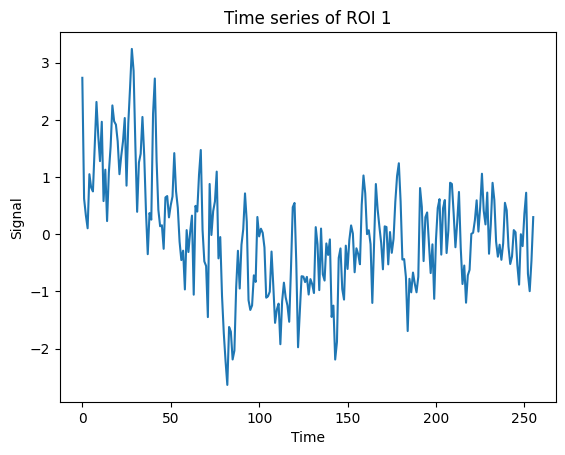

In [6]:
import matplotlib.pyplot as plt

plt.plot(time_series[:, 0])
plt.title("Time series of ROI 1")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.show()  

This plot shows the temporal evolution of the BOLD signal for a single brain region (ROI) across the full duration of the fMRI acquisition.

Each point in the x-axis represents a time point (i.e., one acquired volume), while the y-axis represents the normalized signal intensity for that region. The signal fluctuates around zero because a standardization step has been applied, ensuring that the data has zero mean and unit variance.

The observed variability reflects spontaneous fluctuations in brain activity, which are characteristic of resting-state fMRI data. These fluctuations are not purely random noise; rather, they contain structured temporal information related to underlying neural processes.

From a modeling perspective, this temporal structure is essential. The goal is not to interpret individual signal values in isolation, but to analyze how the signal evolves over time. These temporal dynamics form the basis for defining brain states and studying their transitions, which is the central objective of this project.

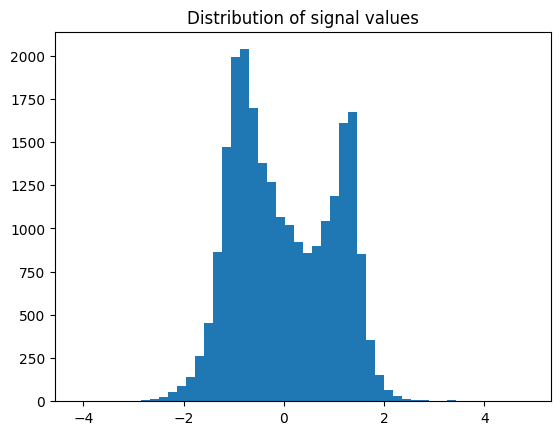

In [7]:
plt.hist(time_series.flatten(), bins=50)
plt.title("Distribution of signal values")
plt.show()

This histogram represents the distribution of all signal values across all brain regions and time points.

By flattening the time series data into a single vector, we can observe the global statistical properties of the dataset. The distribution appears approximately Gaussian and centered around zero, which is consistent with the application of standardization during preprocessing.

This result is important for two reasons. First, it confirms that the normalization step has been correctly applied, ensuring that all regions are on a comparable scale. Second, many statistical and machine learning models assume input data to be centered and scaled. Therefore, having a well-behaved distribution improves the stability and interpretability of subsequent analyses.

Overall, this distribution indicates that the data is properly conditioned and suitable for further modeling steps.

In [8]:
binary_ts = (time_series > 0).astype(int)

X = binary_ts[:-1]
y = binary_ts[1:]

In order to simplify the analysis and enable the definition of discrete brain states, the continuous fMRI signals were transformed into a binary representation.

Specifically, each value in the time series was thresholded at zero: values greater than zero were assigned a value of 1 (active), while values less than or equal to zero were assigned a value of 0 (inactive). This results in a binary matrix where each row represents a time point and each column represents the activation state of a brain region.

This transformation serves several purposes. First, it reduces the impact of noise and small fluctuations in the signal, which are common in fMRI data. Second, it allows us to interpret the brain at each time point as a discrete configuration of active and inactive regions, rather than as a set of continuous values that are harder to model.

Most importantly, this binarization enables the study of temporal transitions between brain states. Instead of predicting continuous signals, the problem becomes one of predicting changes in activation patterns over time. This formulation is more aligned with the objective of modeling brain dynamics and facilitates the application of discrete or probabilistic models.

While this approach simplifies the underlying biological complexity, it provides a practical and interpretable framework for analyzing large-scale brain activity.

# Guppy LLM


## Relation to language models (GuppyLM)

As part of the project context, we consider the relationship between brain state prediction and sequence modeling in language models. The GuppyLM repository provides a minimal implementation of a transformer-based language model, designed to illustrate how modern large language models operate.

Although GuppyLM is not directly applied at this stage, it serves as a conceptual reference. In language modeling, the objective is to predict the next token in a sequence given the previous context. Similarly, in this project, the goal is to predict the next brain state based on the current state. Both problems can be framed as sequence prediction tasks.

For this reason, reviewing GuppyLM helps build intuition about how models learn temporal dependencies and transitions in sequential data. At this stage, the repository will be explored to understand its structure and core components, without integrating it into the pipeline yet. More advanced models inspired by this approach may be considered in later stages of the project.    

# Baseline temporal prediction

As an initial step in modeling brain dynamics, a simple baseline approach is implemented to evaluate whether there is temporal structure in the data.

The idea behind this baseline is straightforward: it assumes that the brain state at the next time point is identical to the current state. In other words, no change is predicted between consecutive time steps. This results in a direct comparison between the current state (X) and the actual next state (y).

To quantify the performance of this approach, the accuracy metric is used. Accuracy is computed as the proportion of correctly predicted elements across all regions and time points. Since the data is binary, this corresponds to the fraction of matches between predicted and actual activation states.

This baseline serves as a reference point. If the accuracy is close to 0.5, it suggests that the data behaves similarly to random noise, with little temporal predictability. However, if the accuracy is significantly higher, it indicates that brain states exhibit temporal stability and structure, meaning that the current state contains useful information about the future state.

Establishing this baseline is essential before applying more complex models, as it allows us to determine whether there is meaningful signal to learn from in the data.


In [9]:
import numpy as np

# baseline: asumir que el siguiente estado es igual al actual
y_pred = X.copy()

# calcular accuracy
accuracy = (y_pred == y).mean()

print("Baseline accuracy:", accuracy)

Baseline accuracy: 0.926001705029838


In [10]:
import numpy as np

# X = estados actuales
# y = siguiente estado
X = binary_ts[:-1]
y = binary_ts[1:]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (255, 92)
y shape: (255, 92)


To evaluate whether brain activity exhibits predictable temporal structure, I implemented a baseline predictive model using logistic regression. The goal is to predict the activation state of each brain region at time 𝑡 + 1 from the full brain state at time t.

This formulation treats the problem as a multi-label classification task, where each region is predicted independently. For each region, a logistic regression model is trained using the binary activation pattern of all regions at the previous time step as input.

This approach allows us to test whether the current global brain configuration contains information about the immediate future, which is directly aligned with the main objective of this project: detecting non-random temporal structure in resting-state brain activity.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Dataset temporal
X = binary_ts[:-1]
y = binary_ts[1:]

n_regions = y.shape[1]

y_pred = np.zeros_like(y)

models = []

# entrenamos un modelo por región
for i in range(n_regions):
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y[:, i])
    
    y_pred[:, i] = model.predict(X)
    models.append(model)

# métricas
accuracy = accuracy_score(y.flatten(), y_pred.flatten())
f1 = f1_score(y.flatten(), y_pred.flatten())

print("Accuracy:", accuracy)
print("F1-score:", f1)

Accuracy: 0.9642369991474851
F1-score: 0.9609858172518019


To assess model performance, I computed both accuracy and F1-score across all regions and time points. While accuracy provides a general measure of correctness, it can be misleading due to class imbalance (inactive states are more frequent). Therefore, the F1-score is a more informative metric, as it balances precision and recall and better reflects the model’s ability to correctly predict activations. After the last results, it appears that the future brain state is not only determined by its own past state, but also by interactions between regions.


Now, to properly evaluate the predictive performance of the model, a temporal train-test split was introduced. Unlike random splitting, which would break the temporal structure of the data, the dataset was divided chronologically: the first 80% of the time points were used for training, and the remaining 20% for testing.

This approach ensures that the model is evaluated on future, unseen data, which better reflects its ability to capture true temporal dependencies rather than simply memorizing patterns. This step is critical in time-series analysis and provides a more realistic assessment of model performance.

In [13]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [14]:
y_pred_test = np.zeros_like(y_test)

for i in range(n_regions):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train[:, i])
    
    y_pred_test[:, i] = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test.flatten(), y_pred_test.flatten())
f1 = f1_score(y_test.flatten(), y_pred_test.flatten())

print("Test Accuracy:", accuracy)
print("Test F1:", f1)

Test Accuracy: 0.9447996589940324
Test F1: 0.9676533033595603
